# Bruker Dektak Profilometer

This notebook quickly covers the plotting of data exported from CMi's Bruker Dektak Profilometer.

The sample used in this notebook is etched silicon nitride on silicon dioxide.

In [1]:
import leman as lm
from leman.loaders import DektakScan
from leman.plotting import plot_dektak_profile
from pathlib import Path
import matplotlib.pyplot as plt

Load our scan and read off the important parameters used in the scan.

In [2]:
path = Path('./data/cmi-bruker-dektak')
profile = DektakScan(
    path = path / "si3n4-c02.csv"
)

print(profile)

DektakScan — 4501 points
  File       : data\cmi-bruker-dektak\si3n4-c02.csv
  Lateral    : 0.0 – 608.0 µm
  Height     : -2933.8 – 291.4 Å
  Resolution : 0.135 µm



we can also get our metadata stored at scan-time.

In [3]:
print(profile.metadata)

{'Date': '22.09.2026', 'Profile': 'Valleys', 'ScanDuration': '15 s', 'ScanLength': '608.31 µm', 'ScanResolution': '0.13512 µm', 'ScanType': 'Standard Scan', 'StylusForce': '2 mg', 'StylusScanRange': '6.5 µm', 'StylusType': 'Radius: 12.5 μm', 'Time': '12:07:02'}


The Dektak records data in angstrom, but we can plot the height profile in nanometers:

(<Figure size 700x300 with 1 Axes>,
 <Axes: xlabel='Lateral position (µm)', ylabel='Height (nm)'>,
 <matplotlib.lines.Line2D at 0x109ad312150>)

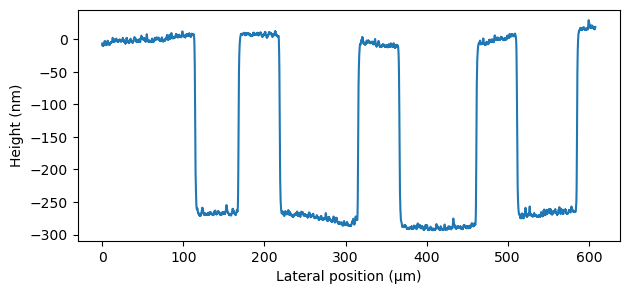

In [4]:
plot_dektak_profile(profile, height_unit = 'nm')

we could also plot it in angstroms if we wished:

(<Figure size 700x300 with 1 Axes>,
 <Axes: xlabel='Lateral position (µm)', ylabel='Height (Å)'>,
 <matplotlib.lines.Line2D at 0x109afa8f980>)

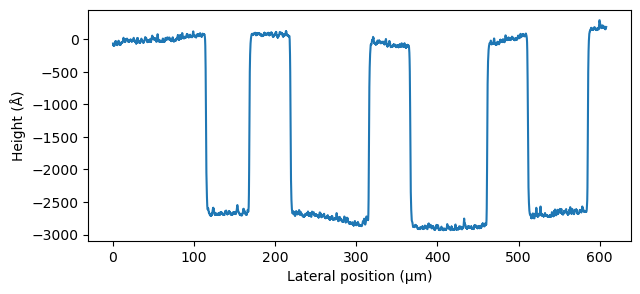

In [5]:
plot_dektak_profile(profile, height_unit = 'angstrom')

On to some features of the class. We can get the height position of a given `x` coordinate with the method `get_value` which returns us a tuple of `(x_pos, height)` where `x_pos` is the nearest recorded `x` position to what was provided as an argument. For example,

In [6]:
x1 = 200
x2 = 300
print(f"The closest x-position to {x1} is {profile.get_value(x1)[0]} which has height {profile.get_value(x1)[1]} angstroms")
print(f"The closest x-position to {x2} is {profile.get_value(x2)[0]} which has height {profile.get_value(x2)[1]} angstroms")

The closest x-position to 200 is 199.977521038457 which has height 72.2013518454501 angstroms
The closest x-position to 300 is 299.966281557686 which has height -2850.42654918697 angstroms


We could also return our height array in `nm` instead of angstrom

In [7]:
profile.height_nm

array([-6.69724355, -8.78264326, -8.71326222, ..., 17.8951701 ,
       17.93777278, 18.70440326], shape=(4501,))

and the array of scanned points

In [8]:
profile.lateral

array([0.00000000e+00, 1.35119947e-01, 2.70239893e-01, ...,
       6.07769520e+02, 6.07904640e+02, 6.08039760e+02], shape=(4501,))

We might also want to differentiate our height profile to identify steps. We can do so with the gradient method

Text(0, 0.5, 'dy/dx')

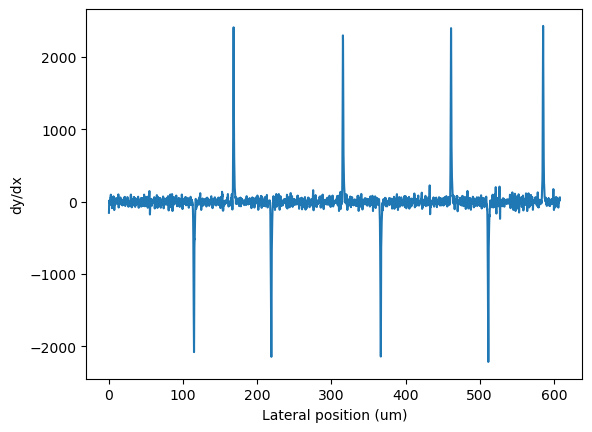

: 

In [ ]:
gradient = profile.gradient
fig, ax = plt.subplots()
ax.plot(profile.lateral, gradient)
ax.set_xlabel("Lateral position (um)")
ax.set_ylabel("dy/dx")